# Scikit-learn Estimators (Algorithms)

## Choosing the Right Algorithm Category

### Classification
**When to use:** Use classification algorithms when you need to predict discrete class labels or categories. Classification is suitable when your target variable is categorical (e.g., spam/not spam, fraud/legitimate, disease/no disease).

### Regression
**When to use:** Use regression algorithms when you need to predict continuous numerical values. Regression is appropriate when your target variable is a real number (e.g., house prices, temperature, sales figures).

### Clustering
**When to use:** Use clustering algorithms when you need to discover inherent groupings in your data without labeled examples. Clustering is an unsupervised learning approach that organizes similar data points into groups.

### Dimensionality Reduction
**When to use:** Use dimensionality reduction techniques when you need to reduce the number of features in your dataset while preserving meaningful information. These techniques help with visualization, addressing the curse of dimensionality, and speeding up model training.

## Classification Algorithms

### SGD Classifier
**When to use:** When dealing with large datasets or when you need online learning capabilities.
**Suitable for:** Linear classification problems with large datasets where memory efficiency is important.

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a large synthetic dataset (10,000 samples) with 20 features
# SGD works well with large datasets and standardized features
X, y = make_classification(
    n_samples=10000, 
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and SGD classifier
clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(max_iter=1000, tol=1e-3)
)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
predictions = clf.predict(X_test)

Accuracy Score: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.81      0.81      1030
           1       0.80      0.81      0.81       970

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



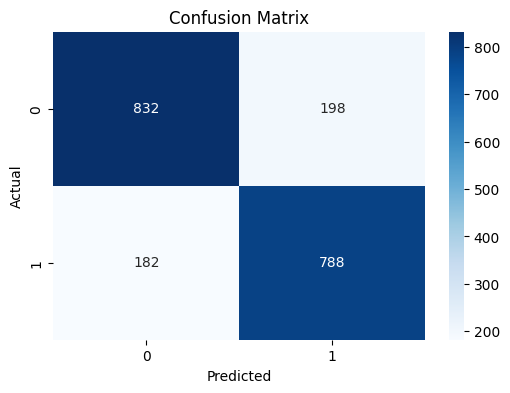

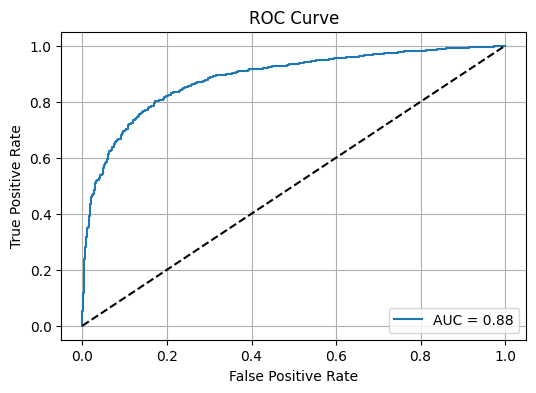

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    roc_auc_score
)

# Create synthetic dataset
X, y = make_classification(
    n_samples=10000, 
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline: Standardize and train SGDClassifier
clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
y_proba = clf.decision_function(X_test)  # For ROC

# === Evaluation Metrics ===
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# === ROC Curve & AUC ===
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Kernel Approximation
**When to use:** When you want to use kernel methods on large datasets but can't afford the computational cost of traditional kernel SVMs.
**Suitable for:** Large datasets where you want kernel-like performance with linear scalability.

In [4]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a non-linear classification dataset with 5000 samples
# Suitable for kernel methods with clear non-linear separation
X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=3,
    class_sep=0.8,
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline

# Create a pipeline with RBF kernel approximation and linear classifier
rbf_feature = RBFSampler(gamma=1, random_state=1)
clf = make_pipeline(
    rbf_feature,
    SGDClassifier(max_iter=1000)
)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
predictions = clf.predict(X_test)

Accuracy Score: 0.504

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.69      0.59       519
           1       0.48      0.30      0.37       481

    accuracy                           0.50      1000
   macro avg       0.50      0.50      0.48      1000
weighted avg       0.50      0.50      0.48      1000



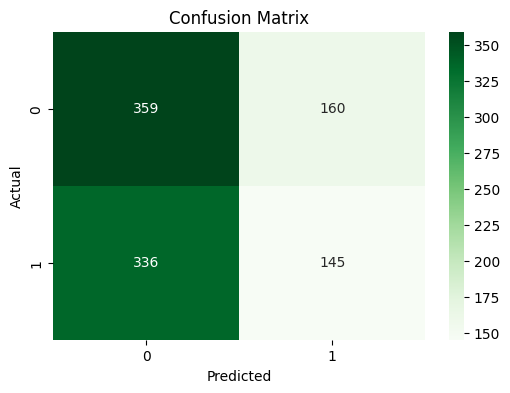

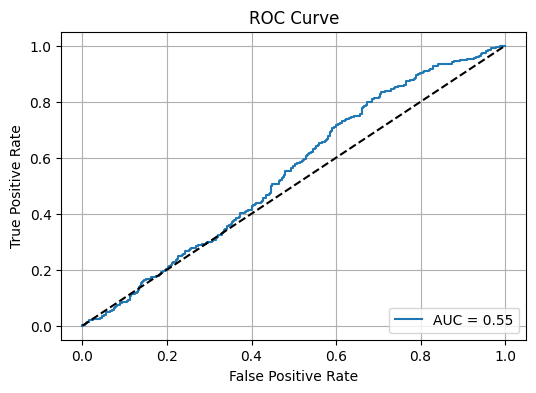

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Create a synthetic non-linear classification dataset
X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=3,
    class_sep=0.8,
    random_state=42
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# RBF kernel approximation + Linear SGD Classifier
rbf_feature = RBFSampler(gamma=1, random_state=1)
clf = make_pipeline(
    rbf_feature,
    SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
)

# Train model
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
y_score = clf.decision_function(X_test)  # for ROC curve

# === Accuracy and Report ===
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# === ROC Curve and AUC ===
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Linear SVC
**When to use:** For linear classification problems when you need better control over regularization and penalties.
**Suitable for:** High-dimensional datasets with clear linear separation.

In [7]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a high-dimensional dataset with linear separation
# Linear SVC works well with high-dimensional data that has clear linear boundaries
X, y = make_classification(
    n_samples=1000,
    n_features=100,  # High-dimensional data
    n_informative=30,
    n_redundant=10,
    class_sep=1.0,  # Clear separation
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and Linear SVC
clf = make_pipeline(
    StandardScaler(),
    LinearSVC(dual=False, tol=1e-3)
)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
predictions = clf.predict(X_test)

Accuracy Score: 0.725

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.66      0.70        96
           1       0.71      0.79      0.75       104

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.72       200
weighted avg       0.73      0.72      0.72       200



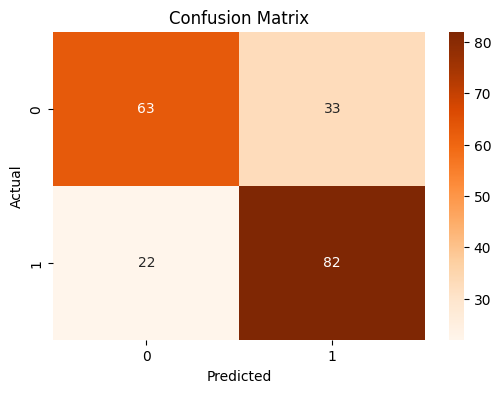

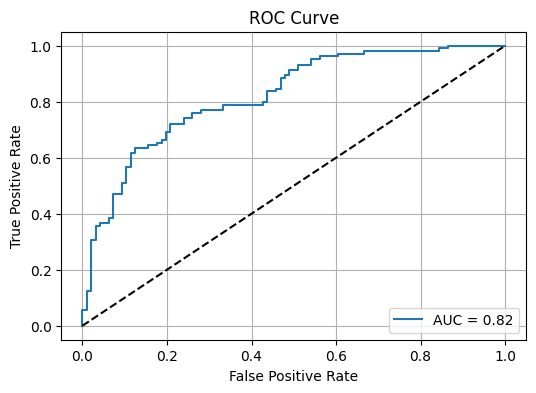

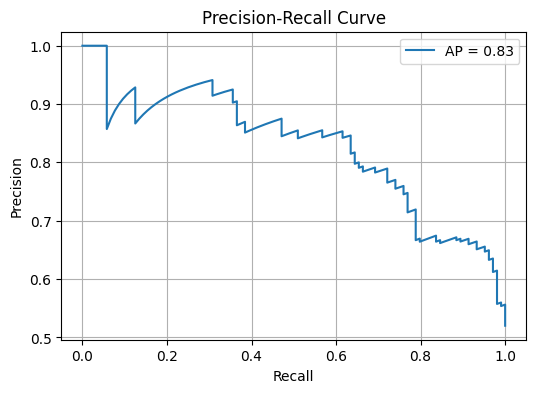

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# High-dimensional linearly separable dataset
X, y = make_classification(
    n_samples=1000,
    n_features=100,
    n_informative=30,
    n_redundant=10,
    class_sep=1.0,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardized pipeline with LinearSVC
clf = make_pipeline(
    StandardScaler(),
    LinearSVC(dual=False, tol=1e-3, random_state=42)
)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
# Decision function for probability-like scores
y_scores = clf.decision_function(X_test)

# === Evaluation ===
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# === ROC Curve ===
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# === Precision-Recall Curve ===
precision, recall, _ = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"AP = {avg_precision:.2f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

### KNeighbors Classifier
**When to use:** When your data has complex local structure and you don't need an explicit model.
**Suitable for:** Lower-dimensional datasets where proximity is meaningful for classification.`

In [10]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a dataset with complex local structure
# KNN works well with datasets where local proximity matters
X, y = make_classification(
    n_samples=1000,
    n_features=5,  # Lower-dimensional data
    n_informative=4,
    n_redundant=1,
    n_clusters_per_class=4,  # Complex local structure
    class_sep=0.8,
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN classifier
clf = KNeighborsClassifier(n_neighbors=5)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
predictions = clf.predict(X_test)

Accuracy Score: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89        95
           1       0.92      0.87      0.89       105

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



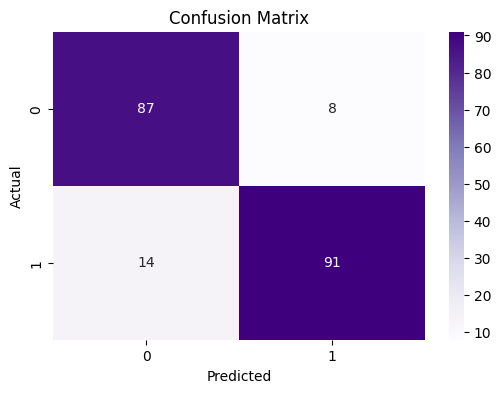

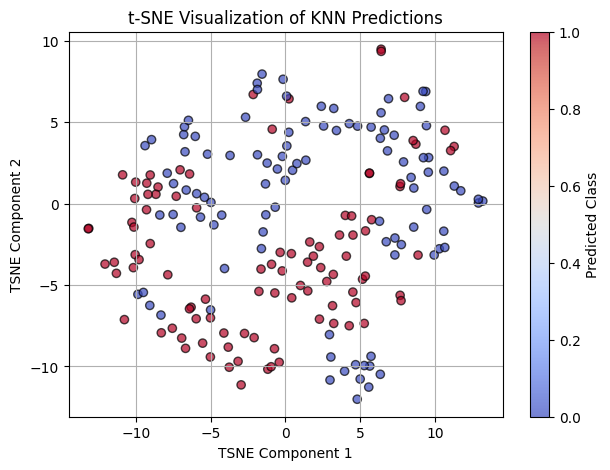

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

# Create classification dataset with complex local structure
X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=4,
    n_redundant=1,
    n_clusters_per_class=4,
    class_sep=0.8,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN classifier
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# === Evaluation ===
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# === t-SNE Projection for Visualization ===
tsne = TSNE(n_components=2, random_state=42)
X_test_2D = tsne.fit_transform(X_test)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_test_2D[:, 0], X_test_2D[:, 1],
    c=y_pred, cmap='coolwarm', edgecolor='k', alpha=0.7
)
plt.title("t-SNE Visualization of KNN Predictions")
plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.colorbar(scatter, label="Predicted Class")
plt.grid(True)
plt.show()

### Ensemble Classifiers
**When to use:** When you want to improve model performance by combining multiple models.
**Suitable for:** Complex problems where a single model might not capture all patterns.

In [13]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a complex dataset with multiple informative features
# Ensemble methods excel with complex datasets that have multiple patterns
X, y = make_classification(
    n_samples=2000,
    n_features=30,
    n_informative=20,
    n_redundant=5,
    n_classes=2,
    n_clusters_per_class=3,
    class_sep=0.75,
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_clf.predict(X_test)
gb_predictions = gb_clf.predict(X_test)

Random Forest Accuracy: 0.805
Gradient Boosting Accuracy: 0.78

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       205
           1       0.79      0.82      0.80       195

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.80       400
weighted avg       0.81      0.81      0.81       400


--- Gradient Boosting Report ---
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       205
           1       0.77      0.79      0.78       195

    accuracy                           0.78       400
   macro avg       0.78      0.78      0.78       400
weighted avg       0.78      0.78      0.78       400



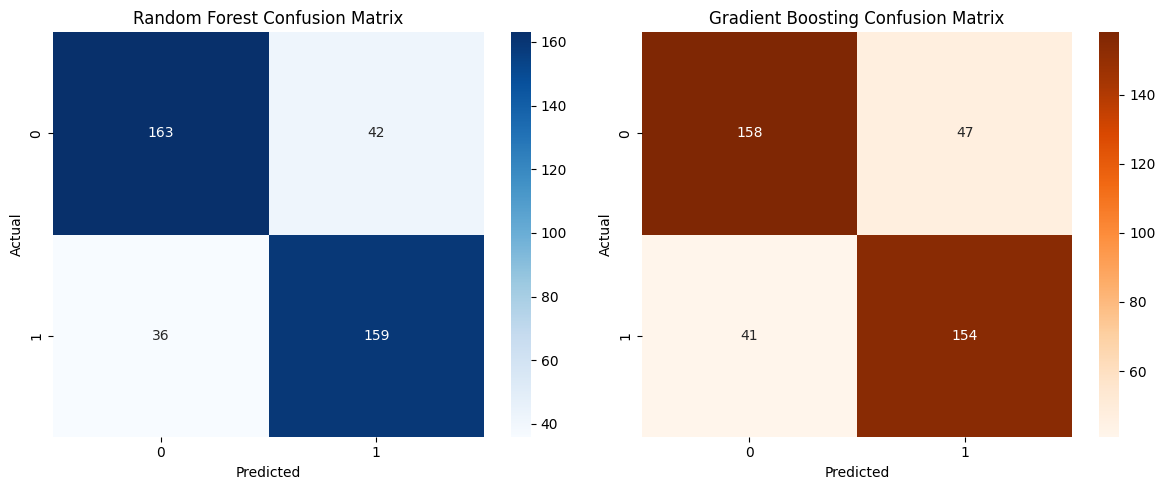

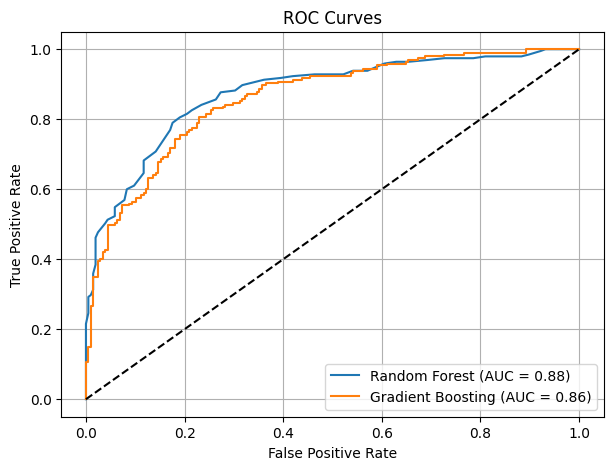

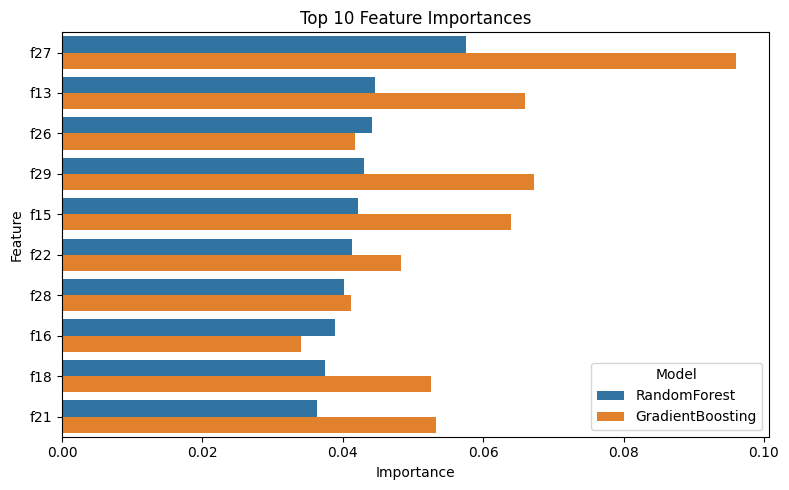

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Generate complex classification dataset
X, y = make_classification(
    n_samples=2000,
    n_features=30,
    n_informative=20,
    n_redundant=5,
    n_classes=2,
    n_clusters_per_class=3,
    class_sep=0.75,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train classifiers
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)

rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)

# Predictions
rf_pred = rf_clf.predict(X_test)
gb_pred = gb_clf.predict(X_test)
rf_scores = rf_clf.predict_proba(X_test)[:, 1]
gb_scores = gb_clf.predict_proba(X_test)[:, 1]

# === Accuracy and Report ===
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

print("\n--- Gradient Boosting Report ---")
print(classification_report(y_test, gb_pred))

# === Confusion Matrices ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, gb_pred), annot=True, fmt='d', cmap='Oranges')
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# === ROC Curves ===
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_scores)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_scores)
auc_rf = roc_auc_score(y_test, rf_scores)
auc_gb = roc_auc_score(y_test, gb_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# === Feature Importances ===
rf_importance = pd.Series(rf_clf.feature_importances_, name="Importance")
gb_importance = pd.Series(gb_clf.feature_importances_, name="Importance")
features = [f"f{i}" for i in range(X.shape[1])]

# Create comparison dataframe
fi_df = pd.DataFrame({
    "Feature": features,
    "RandomForest": rf_importance,
    "GradientBoosting": gb_importance
}).sort_values("RandomForest", ascending=False).head(10)

# Plot top features
fi_df_melted = fi_df.melt(id_vars="Feature", var_name="Model", value_name="Importance")

plt.figure(figsize=(8, 5))
sns.barplot(data=fi_df_melted, x="Importance", y="Feature", hue="Model")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

### SVC
**When to use:** When you need a powerful non-linear classifier with various kernel options.
**Suitable for:** Smaller datasets with complex decision boundaries.

In [16]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a non-linear dataset with clear decision boundaries
# SVC with RBF kernel works well with smaller datasets having non-linear patterns
X, y = make_classification(
    n_samples=800,  # Smaller dataset
    n_features=10,
    n_informative=7,
    n_redundant=3,
    n_clusters_per_class=2,
    class_sep=1.0,
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and SVC
clf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1, gamma='scale')
)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
predictions = clf.predict(X_test)

Accuracy: 0.93125

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93        80
           1       0.91      0.96      0.93        80

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160



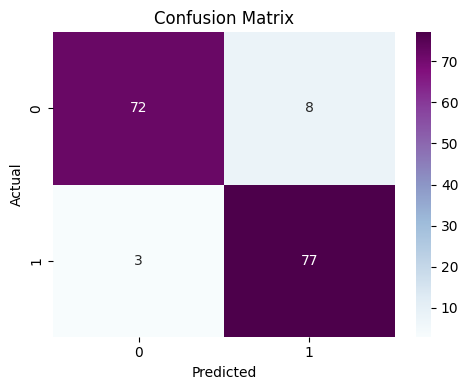

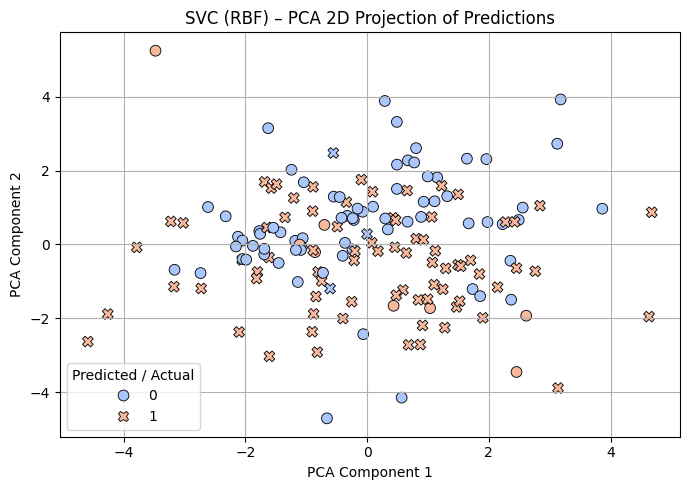

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.decomposition import PCA

# === Data ===
X, y = make_classification(
    n_samples=800,
    n_features=10,
    n_informative=7,
    n_redundant=3,
    n_clusters_per_class=2,
    class_sep=1.0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === Classifier ===
clf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1, gamma='scale', probability=True)
)

clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

# === Evaluation ===
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

# === Confusion Matrix ===
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# === 2D PCA Visualization with Predictions ===
scaler = clf.named_steps['standardscaler']
svc = clf.named_steps['svc']

X_test_scaled = scaler.transform(X_test)
X_pca = PCA(n_components=2).fit_transform(X_test_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=predictions, style=y_test,
                palette='coolwarm', s=60, edgecolor='k')
plt.title("SVC (RBF) – PCA 2D Projection of Predictions")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Predicted / Actual", loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

### Naive Bayes
**When to use:** When you have independent features and need a fast, simple classifier.
**Suitable for:** Text classification, spam filtering, and situations with relatively independent features.

In [19]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a dataset with independent features
# Naive Bayes works well when features are relatively independent
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=0,  # No redundant features
    n_clusters_per_class=1,  # Simple structure
    random_state=42
)

# For text classification, you could use:
# from sklearn.datasets import fetch_20newsgroups
# from sklearn.feature_extraction.text import CountVectorizer
# news = fetch_20newsgroups(subset='train', categories=['alt.atheism', 'talk.religion.misc'])
# X = CountVectorizer().fit_transform(news.data)
# y = news.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.naive_bayes import GaussianNB

# Create Naive Bayes classifier
clf = GaussianNB()

# Train the model
clf.fit(X_train, y_train)

# Make predictions
predictions = clf.predict(X_test)

Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91        83
           1       0.96      0.91      0.93       117

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200



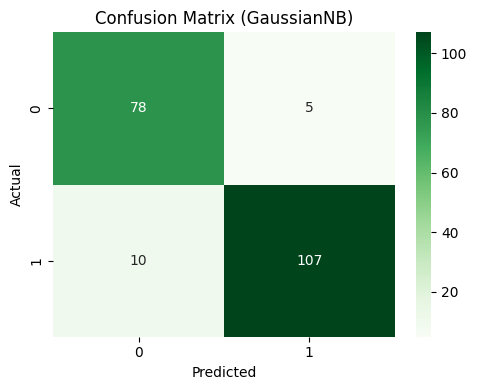


Sample Predictions:
     Actual  Predicted
99        1          1
97        1          1
45        0          0
116       1          1
36        1          1
102       1          1
86        0          0
35        1          1
18        1          1
118       0          0


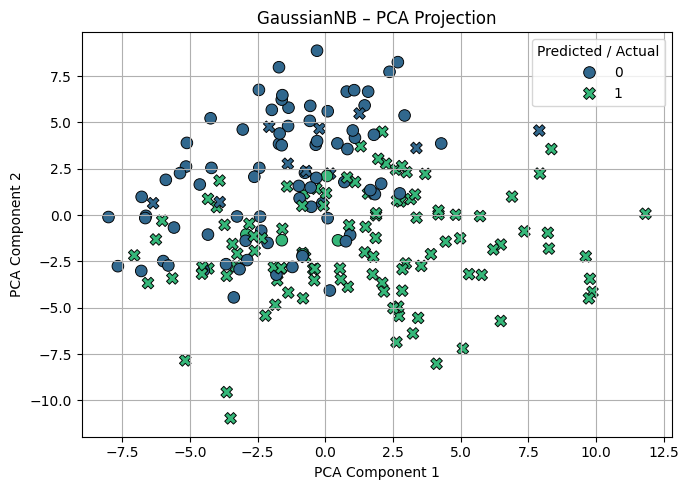

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.decomposition import PCA

# === Dataset ===
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === Naive Bayes Classifier ===
clf = GaussianNB()
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

# === Evaluation ===
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

# === Confusion Matrix ===
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (GaussianNB)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# === Optional: Prediction vs Actual Table ===
df_result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})
print("\nSample Predictions:")
print(df_result.sample(10))

# === 2D PCA Plot ===
X_pca = PCA(n_components=2).fit_transform(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=predictions, style=y_test,
    palette='viridis', s=70, edgecolor='black'
)
plt.title("GaussianNB – PCA Projection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Predicted / Actual", loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

## Regression Algorithms

### SGD Regressor
**When to use:** For large datasets when you need online learning capabilities.
**Suitable for:** Linear regression problems with large datasets where memory efficiency is important.

In [22]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Create a large synthetic regression dataset
# SGD works well with large datasets
X, y = make_regression(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    noise=5.0,
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and SGD regressor
reg = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, tol=1e-3)
)

# Train the model
reg.fit(X_train, y_train)

# Make predictions
predictions = reg.predict(X_test)

R² Score: 0.9993
MAE     : 4.06
MSE     : 25.86
RMSE    : 5.09

Sample Predictions:
      Actual  Predicted  Residual
1253  -19.06     -14.27     -4.80
533  -281.16    -278.98     -2.18
1795  109.79     106.40      3.39
756   332.32     335.20     -2.89
863  -160.58    -159.20     -1.38
380  -108.10     -96.20    -11.90
356    45.30      45.79     -0.49
1197 -292.89    -294.02      1.13
1171  354.89     356.96     -2.07
201   163.38     157.55      5.83


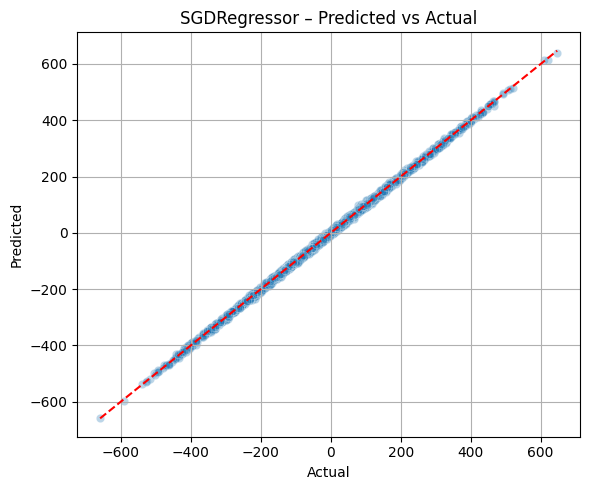

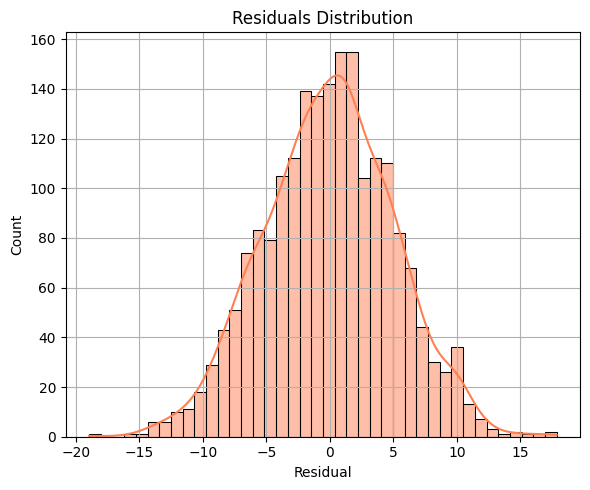

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# === Dataset ===
X, y = make_regression(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    noise=5.0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === SGD Regressor Pipeline ===
reg = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, tol=1e-3)
)

reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

# === Evaluation Metrics ===
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"R² Score: {r2:.4f}")
print(f"MAE     : {mae:.2f}")
print(f"MSE     : {mse:.2f}")
print(f"RMSE    : {rmse:.2f}")

# === DataFrame Sample ===
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions,
    "Residual": y_test - predictions
})
print("\nSample Predictions:")
print(results_df.sample(10).round(2))

# === Predicted vs Actual Plot ===
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("SGDRegressor – Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Residuals Plot ===
plt.figure(figsize=(6, 5))
sns.histplot(results_df["Residual"], bins=40, kde=True, color="coral")
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

### ElasticNet
**When to use:** When you want a balance between Ridge and Lasso regression.
**Suitable for:** Datasets with many correlated features where you want both feature selection and regularization.

In [25]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Create a dataset with many correlated features
# ElasticNet works well with correlated features
X, y = make_regression(
    n_samples=1000,
    n_features=50,
    n_informative=10,
    effective_rank=5,  # Introduces correlation
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and ElasticNet
reg = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
)

# Train the model
reg.fit(X_train, y_train)

# Make predictions
predictions = reg.predict(X_test)

In [27]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# from sklearn.datasets import make_regression
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import ElasticNet
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# # === Data Preparation ===
# X, y = make_regression(
#     n_samples=1000,
#     n_features=50,
#     n_informative=10,
#     effective_rank=5,  # Adds multicollinearity
#     noise=10.0,
#     random_state=42
# )
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # === Pipeline with ElasticNet ===
# reg = make_pipeline(
#     StandardScaler(),
#     ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
# )
# reg.fit(X_train, y_train)
# predictions = reg.predict(X_test)

# # === Evaluation ===
# mae = mean_absolute_error(y_test, predictions)
# mse = mean_squared_error(y_test, predictions)
# rmse = np.sqrt(mse)
# r2 = r2_score(y_test, predictions)

# print(f"R² Score: {r2:.4f}")
# print(f"MAE     : {mae:.2f}")
# print(f"MSE     : {mse:.2f}")
# print(f"RMSE    : {rmse:.2f}")

# # === Predicted vs Actual ===
# plt.figure(figsize=(6, 5))
# sns.scatterplot(x=y_test, y=predictions, alpha=0.3)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel("Actual")
# plt.ylabel("Predicted")
# plt.title("ElasticNet – Predicted vs Actual")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Residuals ===
# residuals = y_test - predictions
# plt.figure(figsize=(6, 5))
# sns.histplot(residuals, bins=30, kde=True, color="skyblue")
# plt.title("Residuals Distribution")
# plt.xlabel("Residual")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Feature Importances ===
# # Extract ElasticNet from pipeline
# enet_model = reg.named_steps['elasticnet']
# coef = enet_model.coef_

# coef_df = pd.DataFrame({
#     "Feature": [f"X{i}" for i in range(X.shape[1])],
#     "Coefficient": coef
# }).sort_values(by="Coefficient", key=abs, ascending=False)

# print("\nTop 10 Features by Absolute Coefficient:")
# print(coef_df.head(10))

# plt.figure(figsize=(10, 5))
# sns.barplot(data=coef_df.head(10), x="Feature", y="Coefficient", palette="viridis")
# plt.title("Top 10 Feature Coefficients")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Sample Predictions DataFrame ===
# results_df = pd.DataFrame({
#     "Actual": y_test,
#     "Predicted": predictions,
#     "Residual": residuals
# })
# print("\nSample Predictions:")
# print(results_df.sample(10).round(2))

```
FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
```

R² Score: -0.0225
MAE     : 8.46
MSE     : 110.12
RMSE    : 10.49


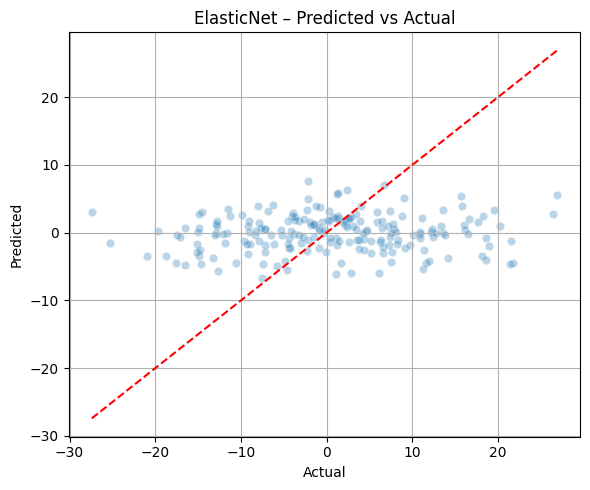

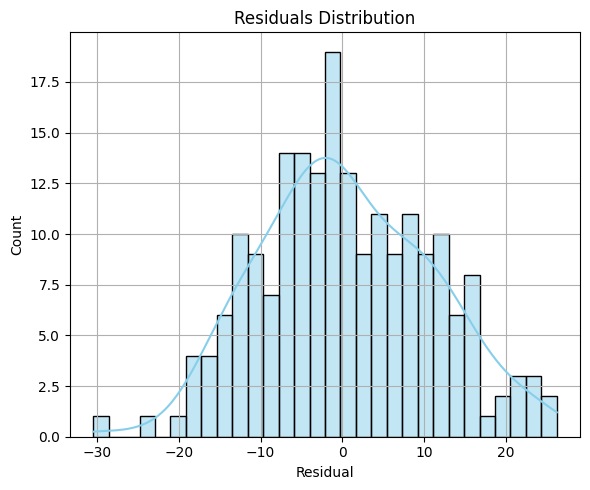


Top 10 Features by Absolute Coefficient:
   Feature  Coefficient
19     X19    -1.475470
33     X33     0.963679
5       X5     0.946473
22     X22     0.875618
17     X17     0.643319
35     X35    -0.632161
25     X25     0.609894
28     X28     0.598584
32     X32     0.536797
3       X3     0.525441


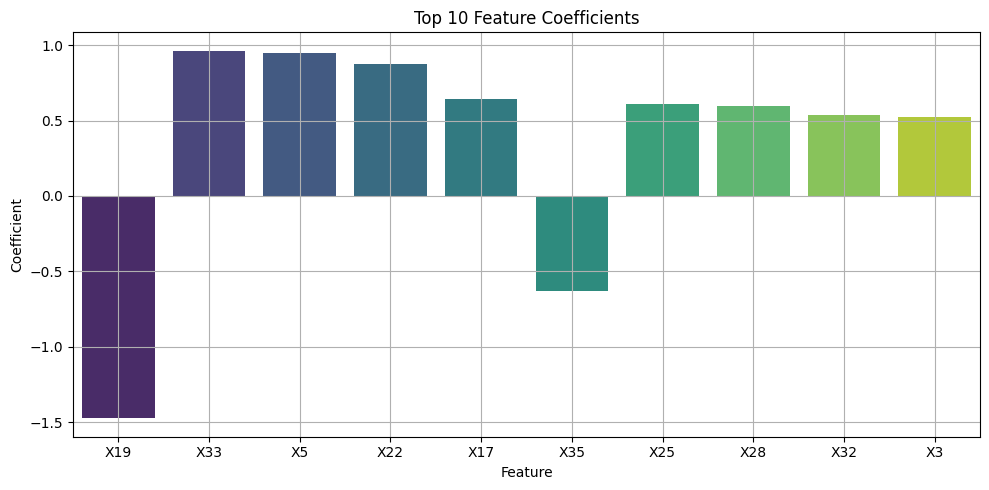


Sample Predictions:
     Actual  Predicted  Residual
28    21.52      -1.27     22.79
112    6.71       6.99     -0.28
74     2.80      -5.99      8.79
92   -17.56      -4.44    -13.12
170   -8.27       0.20     -8.48
111  -13.24      -3.81     -9.43
4      8.37      -1.03      9.40
130   -3.70       1.92     -5.62
96     3.85       1.71      2.13
189   -0.85       0.40     -1.25


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Data Preparation ===
X, y = make_regression(
    n_samples=1000,
    n_features=50,
    n_informative=10,
    effective_rank=5,  # Adds multicollinearity
    noise=10.0,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === Pipeline with ElasticNet ===
reg = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
)
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

# === Evaluation ===
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"R² Score: {r2:.4f}")
print(f"MAE     : {mae:.2f}")
print(f"MSE     : {mse:.2f}")
print(f"RMSE    : {rmse:.2f}")

# === Predicted vs Actual ===
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("ElasticNet – Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Residuals ===
residuals = y_test - predictions
plt.figure(figsize=(6, 5))
sns.histplot(residuals, bins=30, kde=True, color="skyblue")
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Feature Importances ===
# Extract ElasticNet from pipeline
enet_model = reg.named_steps['elasticnet']
coef = enet_model.coef_

coef_df = pd.DataFrame({
    "Feature": [f"X{i}" for i in range(X.shape[1])],
    "Coefficient": coef
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop 10 Features by Absolute Coefficient:")
print(coef_df.head(10))

# === Updated Feature Coefficient Plot ===
plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df.head(10), x="Feature", y="Coefficient", hue="Feature", palette="viridis", legend=False)
plt.title("Top 10 Feature Coefficients")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Sample Predictions DataFrame ===
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions,
    "Residual": residuals
})
print("\nSample Predictions:")
print(results_df.sample(10).round(2))

### Lasso
**When to use:** When you need feature selection and sparse models.
**Suitable for:** High-dimensional datasets where many features may be irrelevant.

In [29]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Create a high-dimensional sparse dataset
# Lasso works well when many features are irrelevant
X, y = make_regression(
    n_samples=1000,
    n_features=100,  # High-dimensional
    n_informative=10,  # Only 10 features are relevant
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and Lasso
reg = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)

# Train the model
reg.fit(X_train, y_train)

# Make predictions
predictions = reg.predict(X_test)

In [31]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# from sklearn.datasets import make_regression
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import Lasso
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# # === Data Preparation ===
# X, y = make_regression(
#     n_samples=1000,
#     n_features=100,
#     n_informative=10,
#     noise=10.0,
#     random_state=42
# )
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # === Pipeline with Lasso ===
# reg = make_pipeline(
#     StandardScaler(),
#     Lasso(alpha=0.1)
# )
# reg.fit(X_train, y_train)
# predictions = reg.predict(X_test)

# # === Evaluation ===
# mae = mean_absolute_error(y_test, predictions)
# mse = mean_squared_error(y_test, predictions)
# rmse = np.sqrt(mse)
# r2 = r2_score(y_test, predictions)

# print(f"R² Score: {r2:.4f}")
# print(f"MAE     : {mae:.2f}")
# print(f"MSE     : {mse:.2f}")
# print(f"RMSE    : {rmse:.2f}")

# # === Predicted vs Actual ===
# plt.figure(figsize=(6, 5))
# sns.scatterplot(x=y_test, y=predictions, alpha=0.3)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel("Actual")
# plt.ylabel("Predicted")
# plt.title("Lasso – Predicted vs Actual")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Residuals ===
# residuals = y_test - predictions
# plt.figure(figsize=(6, 5))
# sns.histplot(residuals, bins=30, kde=True, color="lightcoral")
# plt.title("Residuals Distribution")
# plt.xlabel("Residual")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Feature Coefficients ===
# lasso_model = reg.named_steps['lasso']
# coef = lasso_model.coef_

# coef_df = pd.DataFrame({
#     "Feature": [f"X{i}" for i in range(X.shape[1])],
#     "Coefficient": coef
# }).sort_values(by="Coefficient", key=abs, ascending=False)

# nonzero_coef_count = np.sum(coef != 0)
# print(f"\nNon-zero coefficients: {nonzero_coef_count} / {X.shape[1]}")

# # Display top features
# print("\nTop 10 Features by Absolute Coefficient:")
# print(coef_df.head(10))

# plt.figure(figsize=(10, 5))
# sns.barplot(data=coef_df.head(10), x="Feature", y="Coefficient", palette="magma")
# plt.title("Top 10 Feature Coefficients (Lasso)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Sample Predictions DataFrame ===
# results_df = pd.DataFrame({
#     "Actual": y_test,
#     "Predicted": predictions,
#     "Residual": residuals
# })
# print("\nSample Predictions:")
# print(results_df.sample(10).round(2))

```
FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
```

R² Score: 0.9966
MAE     : 8.01
MSE     : 101.58
RMSE    : 10.08


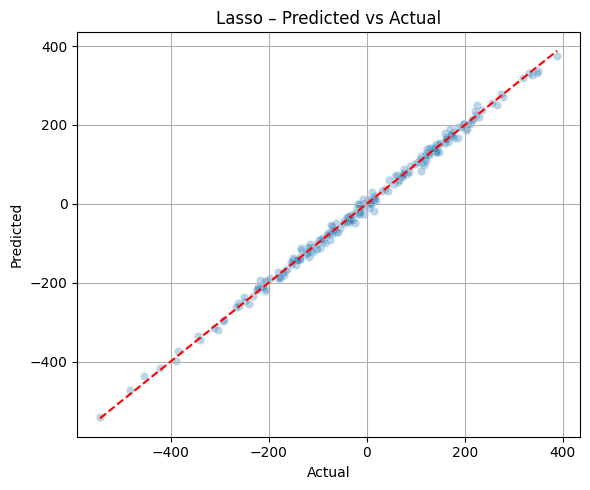

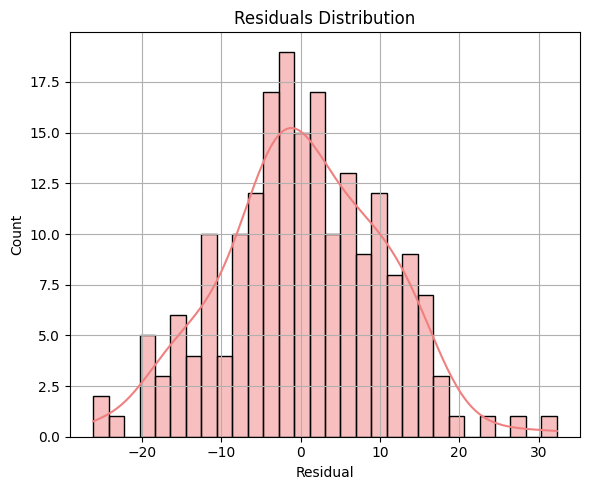


Non-zero coefficients: 82 / 100

Top 10 Features by Absolute Coefficient:
   Feature  Coefficient
56     X56    81.762235
85     X85    75.604142
80     X80    62.644316
90     X90    57.685366
47     X47    48.980923
73     X73    28.282518
87     X87    25.324377
15     X15    20.231192
6       X6     8.402746
66     X66     1.481563


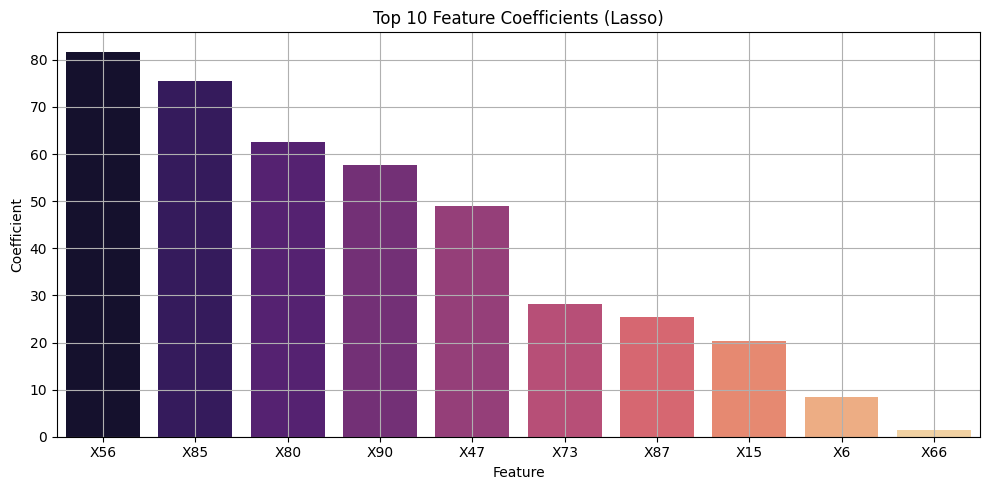


Sample Predictions:
     Actual  Predicted  Residual
16   112.47     102.50      9.97
34     4.99      13.55     -8.55
11  -453.79    -437.49    -16.29
194 -266.36    -261.51     -4.85
85   -35.65     -37.99      2.34
88  -180.21    -187.13      6.91
166 -122.11    -125.10      2.99
191   76.07      88.00    -11.93
123    9.16       1.40      7.76
19    44.15      32.71     11.44


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Data Preparation ===
X, y = make_regression(
    n_samples=1000,
    n_features=100,
    n_informative=10,
    noise=10.0,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === Pipeline with Lasso ===
reg = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

# === Evaluation ===
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"R² Score: {r2:.4f}")
print(f"MAE     : {mae:.2f}")
print(f"MSE     : {mse:.2f}")
print(f"RMSE    : {rmse:.2f}")

# === Predicted vs Actual ===
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso – Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Residuals ===
residuals = y_test - predictions
plt.figure(figsize=(6, 5))
sns.histplot(residuals, bins=30, kde=True, color="lightcoral")
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Feature Coefficients ===
lasso_model = reg.named_steps['lasso']
coef = lasso_model.coef_

coef_df = pd.DataFrame({
    "Feature": [f"X{i}" for i in range(X.shape[1])],
    "Coefficient": coef
}).sort_values(by="Coefficient", key=abs, ascending=False)

nonzero_coef_count = np.sum(coef != 0)
print(f"\nNon-zero coefficients: {nonzero_coef_count} / {X.shape[1]}")

# Display top features
print("\nTop 10 Features by Absolute Coefficient:")
print(coef_df.head(10))

# === Updated Feature Coefficient Plot ===
plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df.head(10), x="Feature", y="Coefficient", hue="Feature", palette="magma", legend=False)
plt.title("Top 10 Feature Coefficients (Lasso)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Sample Predictions DataFrame ===
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions,
    "Residual": residuals
})
print("\nSample Predictions:")
print(results_df.sample(10).round(2))

### Ridge Regression
**When to use:** When you want to penalize large coefficients but keep all features.
**Suitable for:** Datasets with many correlated features.

In [33]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Create a dataset with correlated features
# Ridge works well with correlated features
X, y = make_regression(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    effective_rank=5,  # Creates correlation
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and Ridge regression
reg = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

# Train the model
reg.fit(X_train, y_train)

# Make predictions
predictions = reg.predict(X_test)

In [35]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# from sklearn.datasets import make_regression
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import Ridge
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# # === Data Preparation ===
# X, y = make_regression(
#     n_samples=1000,
#     n_features=20,
#     n_informative=10,
#     effective_rank=5,  # Creates correlation
#     noise=10.0,
#     random_state=42
# )
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # === Pipeline with Ridge Regression ===
# reg = make_pipeline(
#     StandardScaler(),
#     Ridge(alpha=1.0)
# )
# reg.fit(X_train, y_train)
# predictions = reg.predict(X_test)

# # === Evaluation ===
# mae = mean_absolute_error(y_test, predictions)
# mse = mean_squared_error(y_test, predictions)
# rmse = np.sqrt(mse)
# r2 = r2_score(y_test, predictions)

# print(f"R² Score: {r2:.4f}")
# print(f"MAE     : {mae:.2f}")
# print(f"MSE     : {mse:.2f}")
# print(f"RMSE    : {rmse:.2f}")

# # === Predicted vs Actual ===
# plt.figure(figsize=(6, 5))
# sns.scatterplot(x=y_test, y=predictions, alpha=0.3)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel("Actual")
# plt.ylabel("Predicted")
# plt.title("Ridge Regression – Predicted vs Actual")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Residuals ===
# residuals = y_test - predictions
# plt.figure(figsize=(6, 5))
# sns.histplot(residuals, bins=30, kde=True, color="lightblue")
# plt.title("Residuals Distribution")
# plt.xlabel("Residual")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Feature Coefficients ===
# ridge_model = reg.named_steps['ridge']
# coef = ridge_model.coef_

# coef_df = pd.DataFrame({
#     "Feature": [f"X{i}" for i in range(X.shape[1])],
#     "Coefficient": coef
# }).sort_values(by="Coefficient", key=abs, ascending=False)

# nonzero_coef_count = np.sum(coef != 0)
# print(f"\nNon-zero coefficients: {nonzero_coef_count} / {X.shape[1]}")

# # Display top features
# print("\nTop 10 Features by Absolute Coefficient:")
# print(coef_df.head(10))

# plt.figure(figsize=(10, 5))
# sns.barplot(data=coef_df.head(10), x="Feature", y="Coefficient", palette="viridis")
# plt.title("Top 10 Feature Coefficients (Ridge)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Sample Predictions DataFrame ===
# results_df = pd.DataFrame({
#     "Actual": y_test,
#     "Predicted": predictions,
#     "Residual": residuals
# })
# print("\nSample Predictions:")
# print(results_df.sample(10).round(2))

```
FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
```

R² Score: 0.0968
MAE     : 7.68
MSE     : 90.67
RMSE    : 9.52


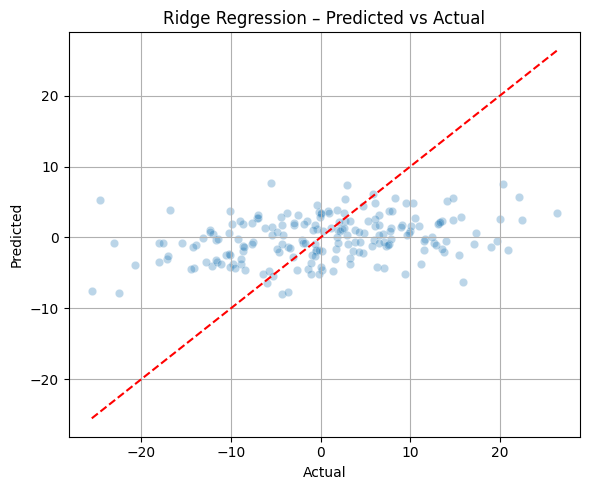

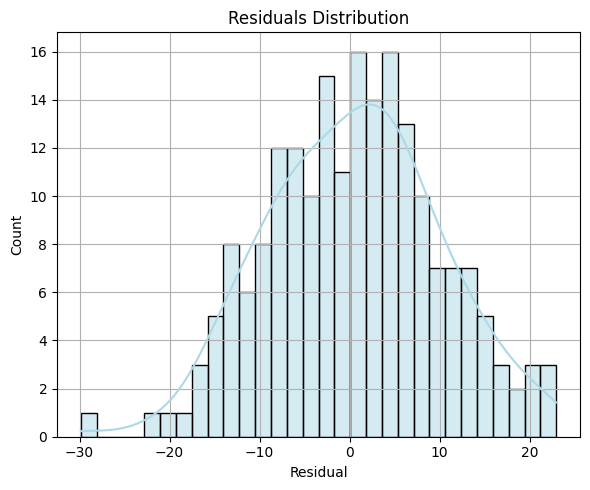


Non-zero coefficients: 20 / 20

Top 10 Features by Absolute Coefficient:
   Feature  Coefficient
18     X18     1.593777
0       X0     1.400775
6       X6     1.134064
13     X13     1.018752
12     X12     0.844391
16     X16    -0.750715
15     X15     0.707227
19     X19     0.690883
5       X5     0.631515
3       X3     0.554437


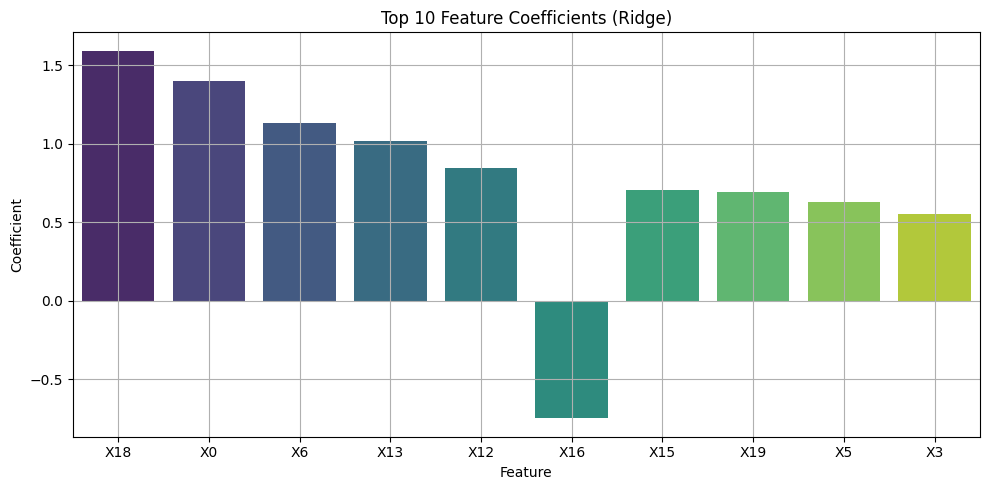


Sample Predictions:
     Actual  Predicted  Residual
191    0.01       3.44     -3.43
159    1.99       2.14     -0.15
8     14.15       5.06      9.08
40    -1.48       2.37     -3.85
138    2.96       0.37      2.59
133    9.50       4.79      4.72
189   -4.25       0.34     -4.59
182   15.45      -2.47     17.92
156   -0.23      -5.10      4.87
54   -15.52      -0.75    -14.76


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Data Preparation ===
X, y = make_regression(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    effective_rank=5,  # Creates correlation
    noise=10.0,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === Pipeline with Ridge Regression ===
reg = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

# === Evaluation ===
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"R² Score: {r2:.4f}")
print(f"MAE     : {mae:.2f}")
print(f"MSE     : {mse:.2f}")
print(f"RMSE    : {rmse:.2f}")

# === Predicted vs Actual ===
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression – Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Residuals ===
residuals = y_test - predictions
plt.figure(figsize=(6, 5))
sns.histplot(residuals, bins=30, kde=True, color="lightblue")
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Feature Coefficients ===
ridge_model = reg.named_steps['ridge']
coef = ridge_model.coef_

coef_df = pd.DataFrame({
    "Feature": [f"X{i}" for i in range(X.shape[1])],
    "Coefficient": coef
}).sort_values(by="Coefficient", key=abs, ascending=False)

nonzero_coef_count = np.sum(coef != 0)
print(f"\nNon-zero coefficients: {nonzero_coef_count} / {X.shape[1]}")

# Display top features
print("\nTop 10 Features by Absolute Coefficient:")
print(coef_df.head(10))

# === Updated Feature Coefficient Plot ===
plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df.head(10), x="Feature", y="Coefficient", hue="Feature", palette="viridis", legend=False)
plt.title("Top 10 Feature Coefficients (Ridge)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Sample Predictions DataFrame ===
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions,
    "Residual": residuals
})
print("\nSample Predictions:")
print(results_df.sample(10).round(2))

### SVR (kernel="linear")
**When to use:** When you need a linear regression model that's robust to outliers.
**Suitable for:** Datasets where you want the benefits of SVM in a regression context with linear relationships.

In [37]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Create a regression dataset with outliers
# Linear SVR is robust to outliers
X, y = make_regression(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    random_state=42
)

# Add some outliers
outlier_indices = np.random.choice(len(y), size=50, replace=False)
y[outlier_indices] += np.random.normal(0, 50, size=50)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and linear SVR
reg = make_pipeline(
    StandardScaler(),
    SVR(kernel='linear', C=1.0)
)

# Train the model
reg.fit(X_train, y_train)

# Make predictions
predictions = reg.predict(X_test)

R² Score: 0.9847
MAE     : 1.37
MSE     : 72.28
RMSE    : 8.50


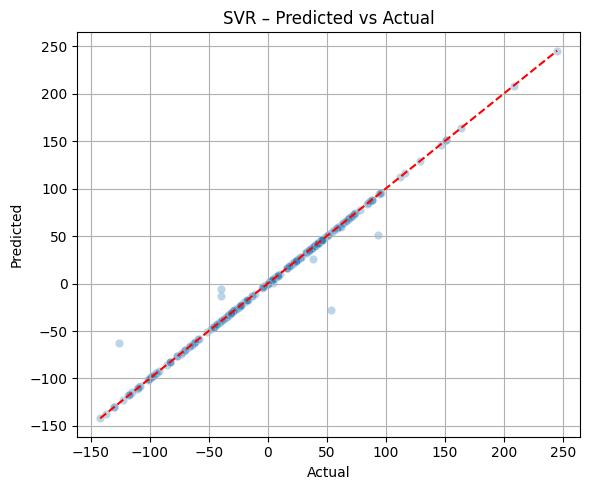

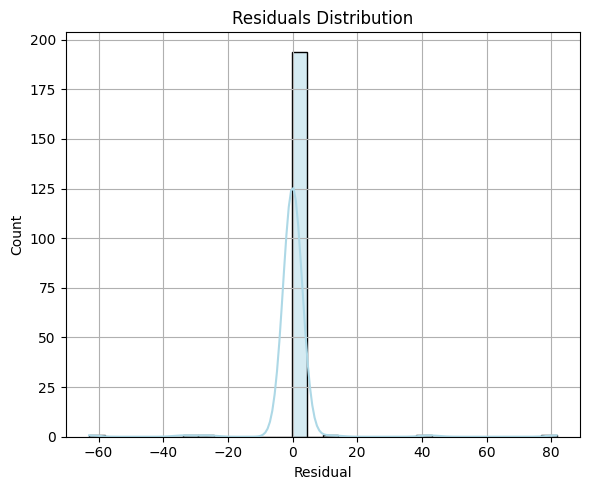


Sample Predictions:
     Actual  Predicted  Residual
162  -65.62     -65.60     -0.02
132 -125.61     -62.64    -62.96
198  -91.90     -91.82     -0.08
30    67.23      67.16      0.07
160   41.56      41.52      0.04
56    39.35      39.28      0.06
19   -25.46     -25.45     -0.02
138  -85.42     -85.33     -0.09
35   -24.50     -24.43     -0.07
136   95.73      95.66      0.07


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Data Preparation ===
X, y = make_regression(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    random_state=42
)

# Add outliers
outlier_indices = np.random.choice(len(y), size=50, replace=False)
y[outlier_indices] += np.random.normal(0, 50, size=50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === Pipeline with Linear SVR ===
reg = make_pipeline(
    StandardScaler(),
    SVR(kernel='linear', C=1.0)
)
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

# === Evaluation ===
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"R² Score: {r2:.4f}")
print(f"MAE     : {mae:.2f}")
print(f"MSE     : {mse:.2f}")
print(f"RMSE    : {rmse:.2f}")

# === Predicted vs Actual ===
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("SVR – Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Residuals ===
residuals = y_test - predictions
plt.figure(figsize=(6, 5))
sns.histplot(residuals, bins=30, kde=True, color="lightblue")
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Sample Predictions DataFrame ===
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions,
    "Residual": residuals
})
print("\nSample Predictions:")
print(results_df.sample(10).round(2))

### Ensemble Regressors
**When to use:** When you want to improve regression performance by combining multiple models.
**Suitable for:** Complex regression problems where a single model might not capture all patterns.

In [40]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Create a complex regression dataset
# Ensemble methods excel with complex relationships
X, y = make_regression(
    n_samples=2000,
    n_features=30,
    n_informative=15,
    random_state=42
)

# Add some non-linearity
y = y + 0.5 * np.sin(X[:, 0]) + 0.5 * np.square(X[:, 1])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_reg.predict(X_test)
gb_predictions = gb_reg.predict(X_test)

Random Forest - R²: 0.6908, MAE: 98.97
Gradient Boosting - R²: 0.8665, MAE: 63.84


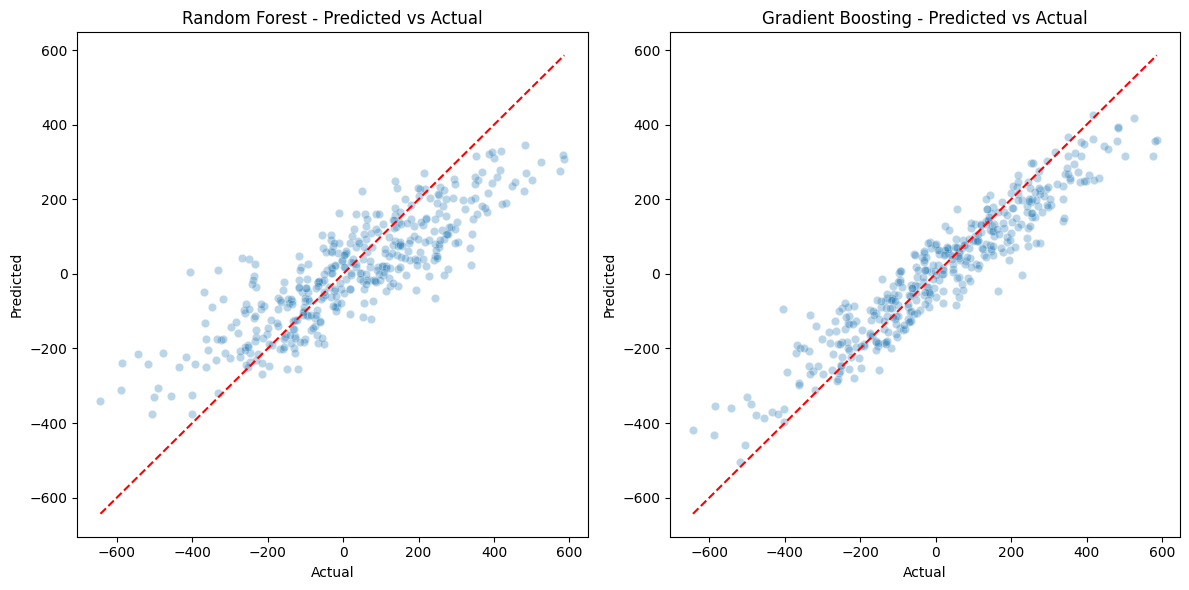

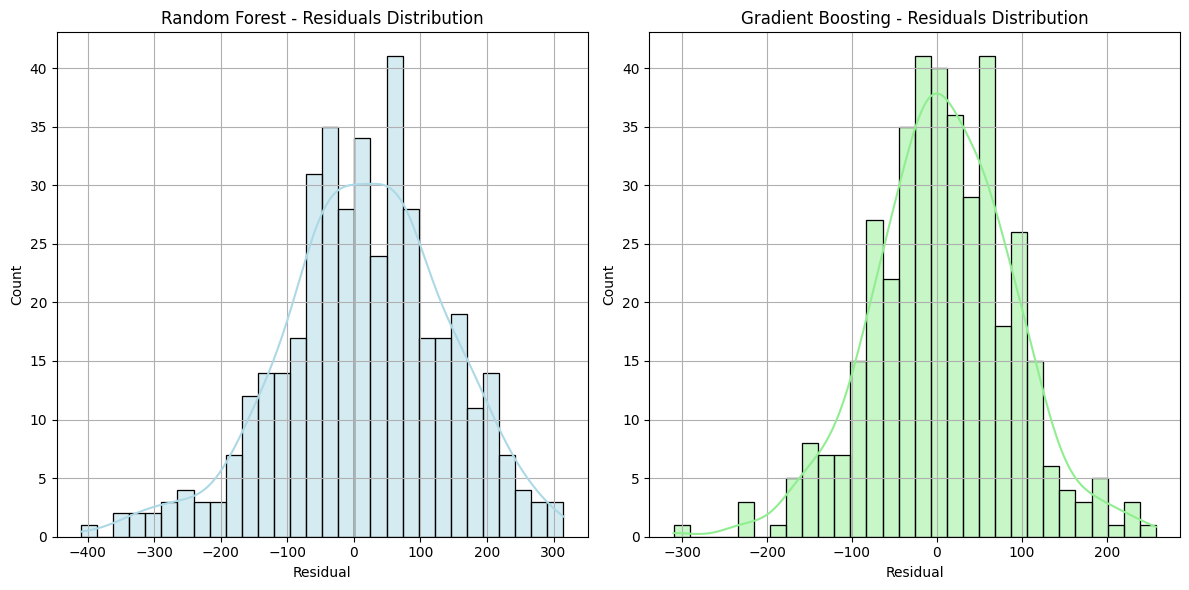


Model Comparison:
               Model  R² Score        MAE
0      Random Forest  0.690821  98.971662
1  Gradient Boosting  0.866520  63.844965


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# === Data Preparation ===
X, y = make_regression(
    n_samples=2000,
    n_features=30,
    n_informative=15,
    random_state=42
)

# Add non-linearity
y = y + 0.5 * np.sin(X[:, 0]) + 0.5 * np.square(X[:, 1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Model Initialization ===
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train the models
rf_reg.fit(X_train, y_train)
gb_reg.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_reg.predict(X_test)
gb_predictions = gb_reg.predict(X_test)

# === Evaluation ===
rf_mae = mean_absolute_error(y_test, rf_predictions)
gb_mae = mean_absolute_error(y_test, gb_predictions)

rf_r2 = r2_score(y_test, rf_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print(f"Random Forest - R²: {rf_r2:.4f}, MAE: {rf_mae:.2f}")
print(f"Gradient Boosting - R²: {gb_r2:.4f}, MAE: {gb_mae:.2f}")

# === Predicted vs Actual ===
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=rf_predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest - Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=gb_predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Gradient Boosting - Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

# === Residuals Distribution ===
rf_residuals = y_test - rf_predictions
gb_residuals = y_test - gb_predictions

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(rf_residuals, bins=30, kde=True, color="lightblue")
plt.title("Random Forest - Residuals Distribution")
plt.xlabel("Residual")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(gb_residuals, bins=30, kde=True, color="lightgreen")
plt.title("Gradient Boosting - Residuals Distribution")
plt.xlabel("Residual")
plt.grid(True)

plt.tight_layout()
plt.show()

# === Model Comparison Table ===
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'R² Score': [rf_r2, gb_r2],
    'MAE': [rf_mae, gb_mae]
})
print("\nModel Comparison:")
print(model_comparison)

### SVR (kernel="rbf")
**When to use:** When your data has non-linear relationships that require a flexible regression model.
**Suitable for:** Complex regression problems with non-linear patterns.

In [43]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Create a non-linear regression dataset
# RBF SVR works well with non-linear patterns
X, y = make_regression(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    random_state=42
)

# Add non-linearity
y = y + 0.7 * np.sin(X[:, 0] * 2) + 0.3 * np.cos(X[:, 1] * 3) + 0.2 * np.square(X[:, 2])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and RBF SVR
reg = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=1.0, gamma='scale')
)

# Train the model
reg.fit(X_train, y_train)

# Make predictions
predictions = reg.predict(X_test)

R² Score: 0.4363
Mean Absolute Error (MAE): 39.02


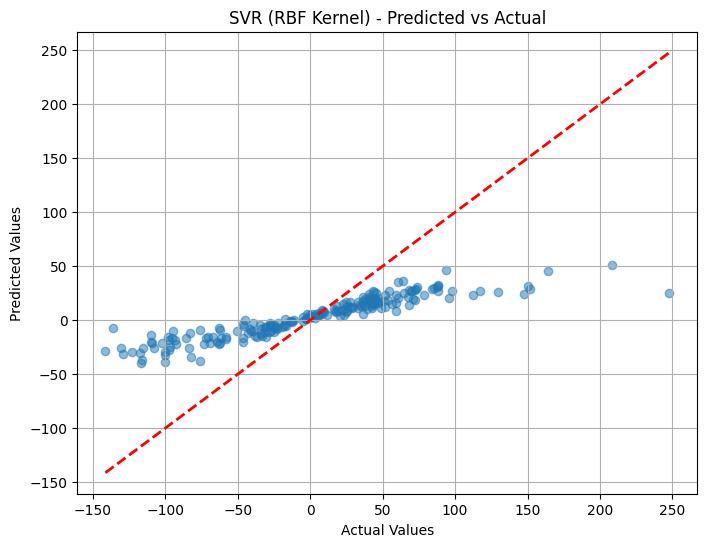

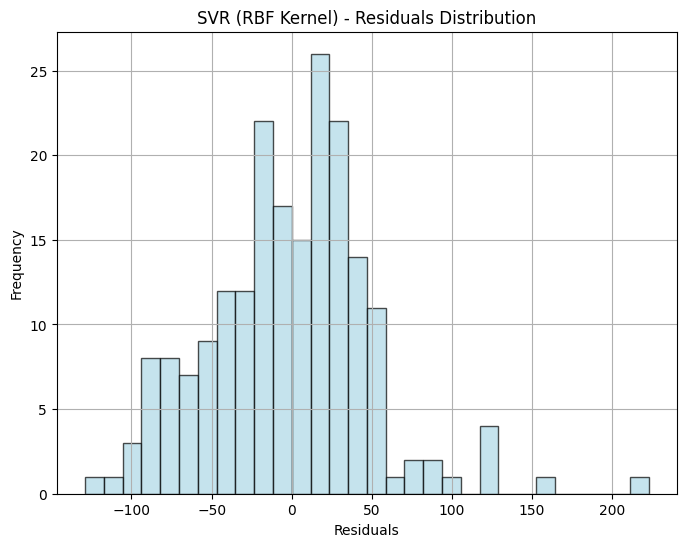

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# === Data Preparation ===
X, y = make_regression(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    random_state=42
)

# Add non-linearity
y = y + 0.7 * np.sin(X[:, 0] * 2) + 0.3 * np.cos(X[:, 1] * 3) + 0.2 * np.square(X[:, 2])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Model Initialization and Training ===
reg = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=1.0, gamma='scale')
)

reg.fit(X_train, y_train)

# === Make Predictions ===
predictions = reg.predict(X_test)

# === Model Evaluation ===
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# === Visualization: Predicted vs Actual ===
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("SVR (RBF Kernel) - Predicted vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.show()

# === Visualization: Residuals ===
residuals = y_test - predictions
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, color="lightblue", edgecolor="black", alpha=0.7)
plt.title("SVR (RBF Kernel) - Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Clustering Algorithms

### KMeans
**When to use:** When you need a simple, fast clustering algorithm with spherical clusters.
**Suitable for:** Data with well-separated, roughly equal-sized, globular clusters.

In [46]:
import numpy as np
from sklearn.datasets import make_blobs

# Create data with well-separated, spherical clusters
# KMeans works best with globular clusters
X, y_true = make_blobs(
    n_samples=1000,
    centers=3,
    cluster_std=0.7,
    random_state=42
)

# For KMeans, we often don't need a test set as it's unsupervised
# But you can split if you want to evaluate on a test set
# X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and KMeans
clustering = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=3, random_state=42)
)

# Fit the clustering model
clustering.fit(X)

# Get cluster assignments
labels = clustering.predict(X)

Silhouette Score: 0.8905


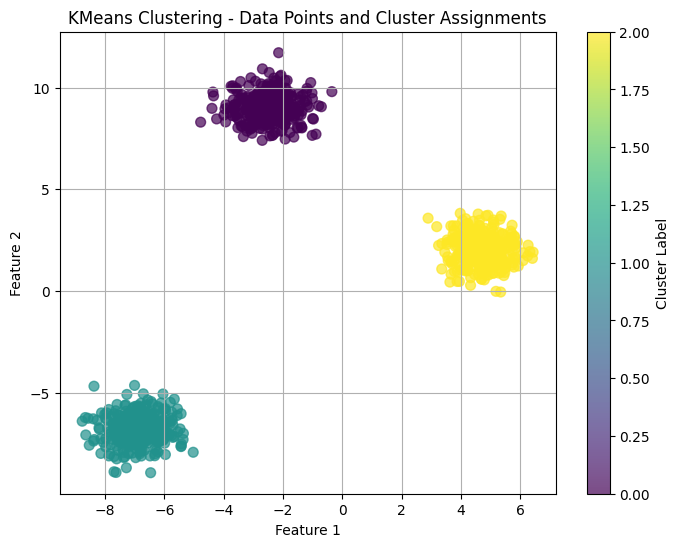

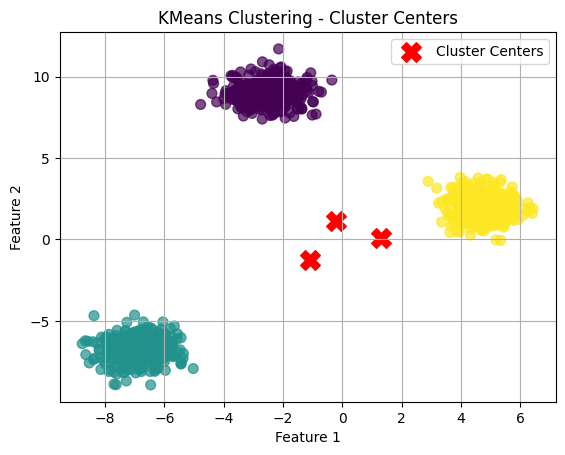

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score

# === Data Preparation ===
X, y_true = make_blobs(
    n_samples=1000,
    centers=3,
    cluster_std=0.7,
    random_state=42
)

# === Model Initialization and Training ===
clustering = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=3, random_state=42)
)

clustering.fit(X)

# === Get Cluster Labels ===
labels = clustering.predict(X)

# === Clustering Evaluation ===
sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score:.4f}")

# === Visualization: Clustered Data Points ===
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title("KMeans Clustering - Data Points and Cluster Assignments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.show()

# === Visualizing Cluster Centers ===
kmeans = clustering.named_steps['kmeans']
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='red', marker='X', label='Cluster Centers')
plt.title("KMeans Clustering - Cluster Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

### Spectral Clustering
**When to use:** When your data forms complex, non-globular shapes.
**Suitable for:** Data where clusters have complex shapes that KMeans would fail to identify.

In [49]:
import numpy as np
from sklearn.datasets import make_moons

# Create data with non-globular, moon-shaped clusters
# Spectral clustering works well with complex shapes
X, y_true = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# For spectral clustering, we typically don't need a test set
# X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [50]:
# from sklearn.cluster import SpectralClustering
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline

# # Create a pipeline with standardization and Spectral Clustering
# clustering = make_pipeline(
#     StandardScaler(),
#     SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
# )

# # Fit the clustering model
# labels = clustering.fit_predict(X)

```
UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
```

In [51]:
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
from sklearn.neighbors import kneighbors_graph

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a connectivity matrix to ensure the graph is connected
# Increase n_neighbors to make the graph more connected
n_neighbors = min(30, len(X) - 1)  # Use more neighbors, but not more than sample size - 1
connectivity = kneighbors_graph(
    X_scaled, 
    n_neighbors=n_neighbors, 
    include_self=True,
    mode='connectivity'
)

# Create Spectral Clustering with the connectivity matrix
clustering = SpectralClustering(
    n_clusters=3,
    affinity='precomputed',  # Use precomputed affinity
    random_state=42,
    assign_labels='kmeans'  # This can help with stability
)

# Create an affinity matrix from the connectivity matrix
# Convert the sparse matrix to a dense format for the affinity
affinity_matrix = 0.5 * (connectivity + connectivity.T)

# Fit the clustering model with the affinity matrix
labels = clustering.fit_predict(affinity_matrix)

In [52]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.datasets import make_moons
# from sklearn.cluster import SpectralClustering
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline

# # === Data Preparation ===
# X, y_true = make_moons(
#     n_samples=500,
#     noise=0.05,
#     random_state=42
# )

# # === Model Initialization and Training ===
# clustering = make_pipeline(
#     StandardScaler(),
#     SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42)
# )

# labels = clustering.fit_predict(X)

# # === Visualization: Clustered Data Points ===
# plt.figure(figsize=(8, 6))
# plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
# plt.title("Spectral Clustering - Data Points and Cluster Assignments")
# plt.xlabel("Feature 1")
# plt.ylabel("Feature 2")
# plt.grid(True)
# plt.colorbar(label='Cluster Label')
# plt.show()

```
UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
```

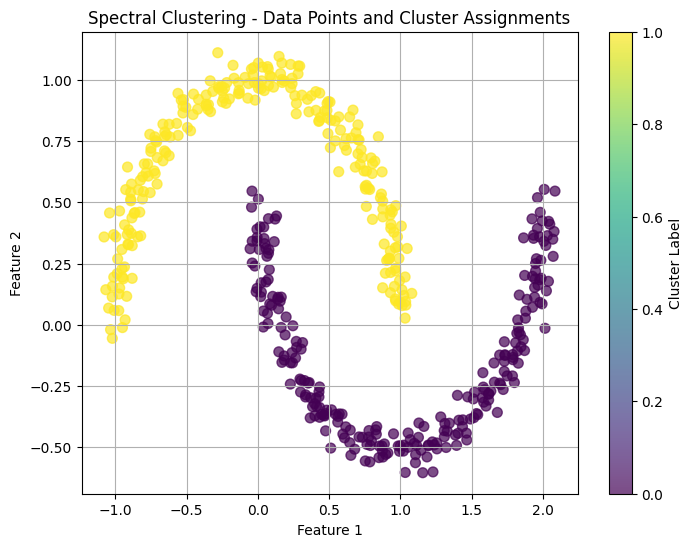

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph

# === Data Preparation ===
X, y_true = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# === Preprocessing and Graph Construction ===
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a connectivity matrix to ensure the graph is connected
# For the moons dataset, we need enough neighbors to capture the structure
n_neighbors = min(30, len(X) - 1)  # Use more neighbors, but not more than sample size - 1
connectivity = kneighbors_graph(
    X_scaled, 
    n_neighbors=n_neighbors, 
    include_self=True,
    mode='connectivity'
)

# Create an affinity matrix from the connectivity matrix
# Convert the sparse matrix to a dense format for the affinity
affinity_matrix = 0.5 * (connectivity + connectivity.T)

# === Model Training ===
# Create Spectral Clustering with the connectivity matrix
clustering = SpectralClustering(
    n_clusters=2,
    affinity='precomputed',  # Use precomputed affinity
    random_state=42,
    assign_labels='kmeans'  # This can help with stability
)

# Fit the clustering model with our custom affinity matrix
labels = clustering.fit_predict(affinity_matrix)

# === Visualization: Clustered Data Points ===
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title("Spectral Clustering - Data Points and Cluster Assignments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.show()

### GMM (Gaussian Mixture Models)
**When to use:** When your data consists of overlapping clusters of different sizes and shapes.
**Suitable for:** Data that can be modeled as a mixture of Gaussian distributions.

In [54]:
# import numpy as np
# from sklearn.datasets import make_blobs

# # Create overlapping clusters of different sizes and shapes
# # GMM works well with Gaussian-distributed clusters
# X, y_true = make_blobs(
#     n_samples=[100, 200, 300],  # Different cluster sizes
#     centers=3,
#     cluster_std=[0.5, 1.0, 1.5],  # Different standard deviations
#     random_state=42
# )

# # Add some random rotation to create different shapes
# from sklearn.preprocessing import StandardScaler
# X = StandardScaler().fit_transform(X)

# # For GMM, we typically don't need a test set
# # X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

```
ValueError: Parameter `centers` must be array-like. Got 3 instead
```

In [55]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Create overlapping clusters of different sizes and shapes
# GMM works well with Gaussian-distributed clusters
X, y_true = make_blobs(
    n_samples=[100, 200, 300],  # Different cluster sizes
    centers=[[0, 0], [4, 4], [-4, -4]],  # Define actual center coordinates
    cluster_std=[0.5, 1.0, 1.5],  # Different standard deviations
    random_state=42
)

# Add some random rotation to create different shapes
X = StandardScaler().fit_transform(X)

# For GMM, we typically don't need a test set
# X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [56]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and GMM
clustering = make_pipeline(
    StandardScaler(),
    GaussianMixture(n_components=3, random_state=42)
)

# Fit the model
clustering.fit(X)

# Get cluster assignments
labels = clustering[-1].predict(clustering[0].transform(X))

In [57]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.datasets import make_blobs
# from sklearn.mixture import GaussianMixture
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline

# # === Data Preparation ===
# X, y_true = make_blobs(
#     n_samples=[100, 200, 300],  # Different cluster sizes
#     centers=3,
#     cluster_std=[0.5, 1.0, 1.5],  # Different standard deviations
#     random_state=42
# )

# # Add random rotation to create different shapes
# X = StandardScaler().fit_transform(X)

# # === Model Initialization and Training ===
# clustering = make_pipeline(
#     StandardScaler(),
#     GaussianMixture(n_components=3, random_state=42)
# )

# # Fit the model
# clustering.fit(X)

# # Get cluster assignments
# labels = clustering[-1].predict(clustering[0].transform(X))

# # === Visualization: Clustered Data Points ===
# plt.figure(figsize=(8, 6))
# plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
# plt.title("GMM Clustering - Data Points and Cluster Assignments")
# plt.xlabel("Feature 1")
# plt.ylabel("Feature 2")
# plt.grid(True)
# plt.colorbar(label='Cluster Label')
# plt.show()

```
ValueError: Parameter `centers` must be array-like. Got 3 instead
```

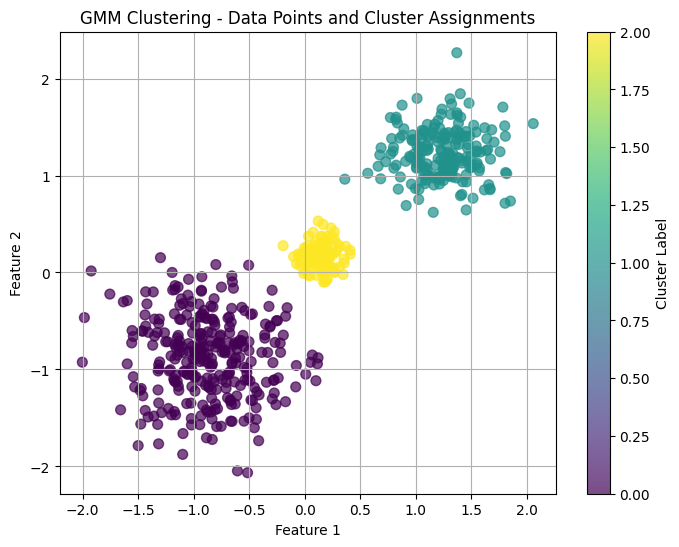

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# === Data Preparation ===
X, y_true = make_blobs(
    n_samples=[100, 200, 300],  # Different cluster sizes
    centers=[[0, 0], [4, 4], [-4, -4]],  # Define actual center coordinates
    cluster_std=[0.5, 1.0, 1.5],  # Different standard deviations
    random_state=42
)

# Add random rotation to create different shapes
X = StandardScaler().fit_transform(X)

# === Model Initialization and Training ===
clustering = make_pipeline(
    StandardScaler(),
    GaussianMixture(n_components=3, random_state=42)
)

# Fit the model
clustering.fit(X)

# Get cluster assignments
labels = clustering[-1].predict(clustering[0].transform(X))

# === Visualization: Clustered Data Points ===
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title("GMM Clustering - Data Points and Cluster Assignments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.show()

### MiniBatch KMeans
**When to use:** When you have large datasets and need a faster version of KMeans.
**Suitable for:** Very large datasets where standard KMeans would be too slow.

In [59]:
import numpy as np
from sklearn.datasets import make_blobs

# Create a large dataset with well-separated clusters
# MiniBatch KMeans is designed for large datasets
X, y_true = make_blobs(
    n_samples=100000,  # Large dataset
    centers=3,
    cluster_std=0.7,
    random_state=42
)

# For MiniBatch KMeans, we often don't need a test set
# X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [60]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and MiniBatch KMeans
clustering = make_pipeline(
    StandardScaler(),
    MiniBatchKMeans(n_clusters=3, batch_size=100, random_state=42)
)

# Fit the model
clustering.fit(X)

# Get cluster assignments
labels = clustering.predict(X)

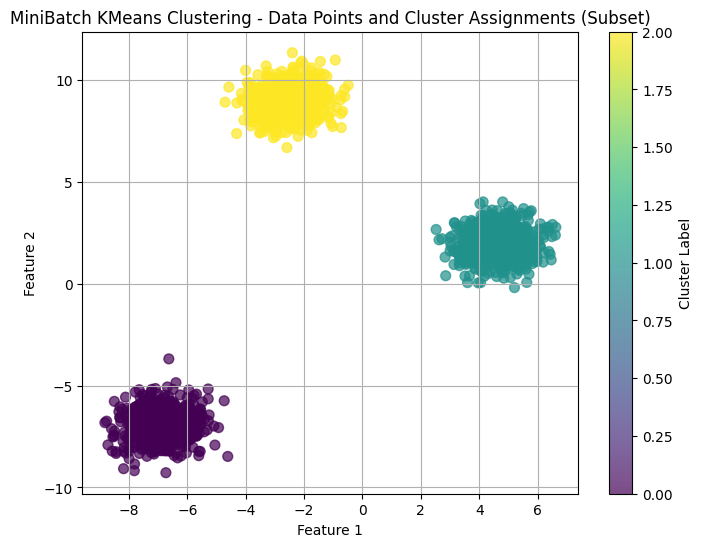

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# === Data Preparation ===
X, y_true = make_blobs(
    n_samples=100000,  # Large dataset
    centers=3,
    cluster_std=0.7,
    random_state=42
)

# === Model Initialization and Training ===
clustering = make_pipeline(
    StandardScaler(),
    MiniBatchKMeans(n_clusters=3, batch_size=100, random_state=42)
)

# Fit the model
clustering.fit(X)

# Get cluster assignments
labels = clustering.predict(X)

# === Visualization: Clustered Data Points ===
# Only visualize a subset for clarity (sampling from the large dataset)
subset_X = X[:2000]
subset_labels = labels[:2000]

plt.figure(figsize=(8, 6))
plt.scatter(subset_X[:, 0], subset_X[:, 1], c=subset_labels, cmap='viridis', s=50, alpha=0.7)
plt.title("MiniBatch KMeans Clustering - Data Points and Cluster Assignments (Subset)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.show()

### MeanShift
**When to use:** When you don't know the number of clusters in advance and want to discover them.
**Suitable for:** Data with an unknown number of clusters of varying shapes and sizes.

In [62]:
import numpy as np
from sklearn.datasets import make_blobs

# Create data with clusters of different densities
# MeanShift automatically finds cluster centers based on density
X, y_true = make_blobs(
    n_samples=1000,
    centers=[[0, 0], [5, 5], [-5, -5]],
    cluster_std=[0.5, 1.0, 1.5],  # Different densities
    random_state=42
)

# For MeanShift, we typically don't need a test set
# X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [63]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Estimate bandwidth for MeanShift
bandwidth = estimate_bandwidth(X, quantile=0.2)

# Create a pipeline with standardization and MeanShift
clustering = make_pipeline(
    StandardScaler(),
    MeanShift(bandwidth=bandwidth, bin_seeding=True)
)

# Fit the model
clustering.fit(X)

# Get cluster assignments
labels = clustering.predict(X)

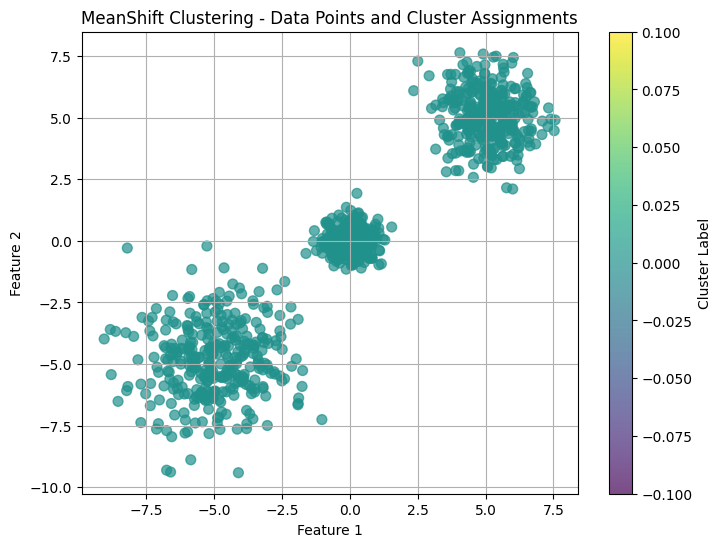

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# === Data Preparation ===
X, y_true = make_blobs(
    n_samples=1000,
    centers=[[0, 0], [5, 5], [-5, -5]],  # Different centers for clusters
    cluster_std=[0.5, 1.0, 1.5],  # Different densities for each cluster
    random_state=42
)

# === Bandwidth Estimation for MeanShift ===
bandwidth = estimate_bandwidth(X, quantile=0.2)

# === Model Initialization and Training ===
clustering = make_pipeline(
    StandardScaler(),
    MeanShift(bandwidth=bandwidth, bin_seeding=True)
)

# Fit the model
clustering.fit(X)

# Get cluster assignments
labels = clustering.predict(X)

# === Visualization: Clustered Data Points ===
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title("MeanShift Clustering - Data Points and Cluster Assignments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.show()

### VBGMM (Variational Bayesian Gaussian Mixture)
**When to use:** When you want to automatically determine the number of clusters.
**Suitable for:** Data where the number of components is not known in advance.

In [65]:
import numpy as np
from sklearn.datasets import make_blobs

# Create data with an unknown number of clusters
# VBGMM can automatically determine the number of components
X, y_true = make_blobs(
    n_samples=1000,
    centers=5,  # Set a higher number than we expect to find
    cluster_std=[0.5, 0.8, 1.0, 1.2, 1.5],
    random_state=42
)

# For VBGMM, we typically don't need a test set
# X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [66]:
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and Bayesian GMM
clustering = make_pipeline(
    StandardScaler(),
    BayesianGaussianMixture(n_components=10, weight_concentration_prior=0.1, random_state=42)
)

# Fit the model
clustering.fit(X)

# Get cluster assignments
labels = clustering[-1].predict(clustering[0].transform(X))

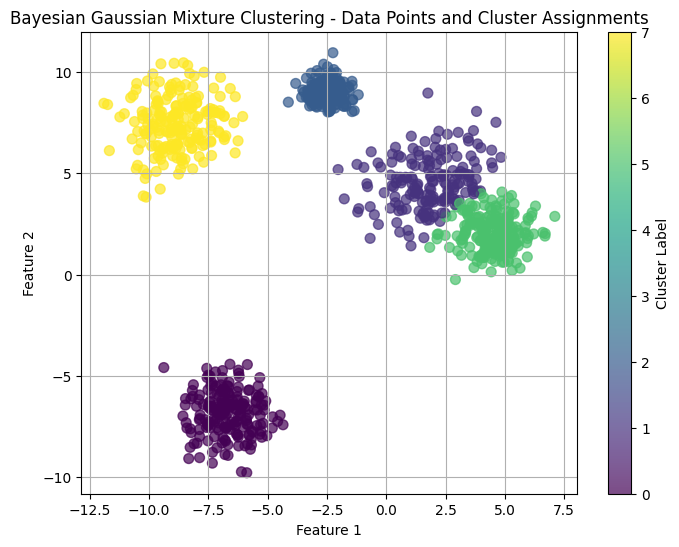

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# === Data Preparation ===
X, y_true = make_blobs(
    n_samples=1000,
    centers=5,  # Set a higher number of centers than we expect to find
    cluster_std=[0.5, 0.8, 1.0, 1.2, 1.5],  # Different densities for each cluster
    random_state=42
)

# === Model Initialization and Training ===
clustering = make_pipeline(
    StandardScaler(),
    BayesianGaussianMixture(n_components=10, weight_concentration_prior=0.1, random_state=42)
)

# Fit the model
clustering.fit(X)

# Get cluster assignments
labels = clustering[-1].predict(clustering[0].transform(X))

# === Visualization: Clustered Data Points ===
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title("Bayesian Gaussian Mixture Clustering - Data Points and Cluster Assignments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.show()

## Dimensionality Reduction Algorithms

### Randomized PCA
**When to use:** When you need to reduce dimensions efficiently on large datasets.
**Suitable for:** High-dimensional datasets where computational efficiency is important.

In [68]:
import numpy as np
from sklearn.datasets import make_classification

# Create a high-dimensional dataset
# Randomized PCA is efficient for high-dimensional data
X, y = make_classification(
    n_samples=2000,
    n_features=100,  # High-dimensional
    n_informative=10,
    n_redundant=90,
    random_state=42
)

# For dimensionality reduction, we typically fit on the full dataset
# No need for train/test split, unless you're using the reduced features for a supervised task

In [69]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and Randomized PCA
dim_reduction = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, svd_solver='randomized', random_state=42)
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

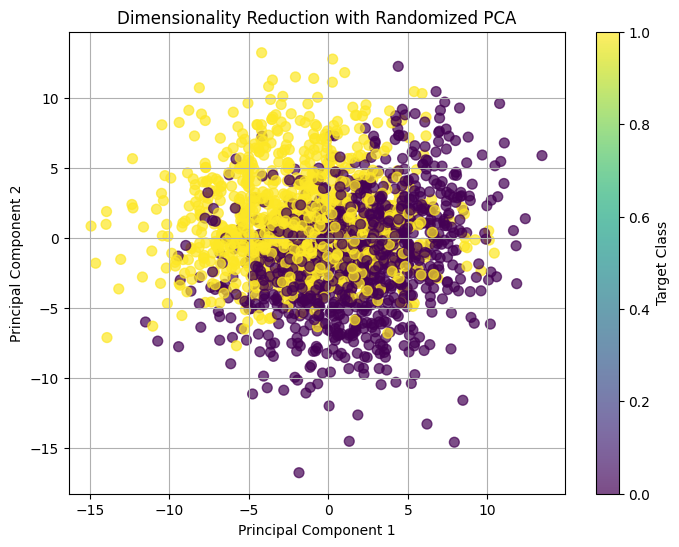

In [70]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# === Data Creation: High-dimensional Classification Dataset ===
X, y = make_classification(
    n_samples=2000,
    n_features=100,  # High-dimensional
    n_informative=10,
    n_redundant=90,  # Many redundant features
    random_state=42
)

# === Dimensionality Reduction using Randomized PCA ===
dim_reduction = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, svd_solver='randomized', random_state=42)
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

# === Visualization: Reduced Dimensions ===
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
plt.title("Dimensionality Reduction with Randomized PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Target Class')
plt.grid(True)
plt.show()

### Spectral Embedding
**When to use:** When you need a non-linear dimensionality reduction that preserves local relationships.
**Suitable for:** Data where local structure is important and linear methods fail.

In [71]:
import numpy as np
from sklearn.datasets import make_swiss_roll

# Create a Swiss roll dataset
# Spectral embedding works well with manifold data
X, color = make_swiss_roll(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

# For dimensionality reduction, we typically fit on the full dataset
# No need for train/test split, unless you're using the reduced features for a supervised task

In [72]:
from sklearn.manifold import SpectralEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and Spectral Embedding
dim_reduction = make_pipeline(
    StandardScaler(),
    SpectralEmbedding(n_components=2, random_state=42)
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

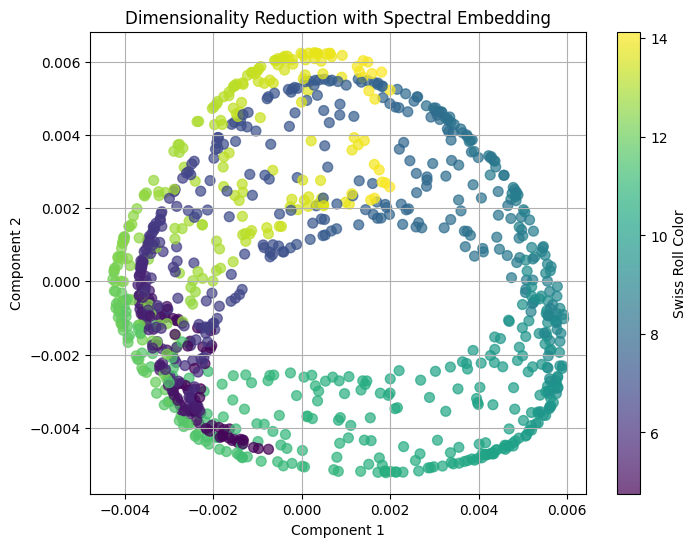

In [73]:
import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import SpectralEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# === Data Creation: Swiss Roll Dataset ===
X, color = make_swiss_roll(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

# === Dimensionality Reduction using Spectral Embedding ===
dim_reduction = make_pipeline(
    StandardScaler(),
    SpectralEmbedding(n_components=2, random_state=42)
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

# === Visualization: Reduced Dimensions ===
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=color, cmap='viridis', s=50, alpha=0.7)
plt.title("Dimensionality Reduction with Spectral Embedding")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label='Swiss Roll Color')
plt.grid(True)
plt.show()

### IsoMap
**When to use:** When you want to preserve geodesic distances between points.
**Suitable for:** Data that lies on a non-linear manifold, like a "Swiss roll".

In [74]:
import numpy as np
from sklearn.datasets import make_swiss_roll

# Create a Swiss roll dataset
# IsoMap is designed for manifold data like the Swiss roll
X, color = make_swiss_roll(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

# For dimensionality reduction, we typically fit on the full dataset
# No need for train/test split, unless you're using the reduced features for a supervised task

In [75]:
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and Isomap
dim_reduction = make_pipeline(
    StandardScaler(),
    Isomap(n_components=2, n_neighbors=5)
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

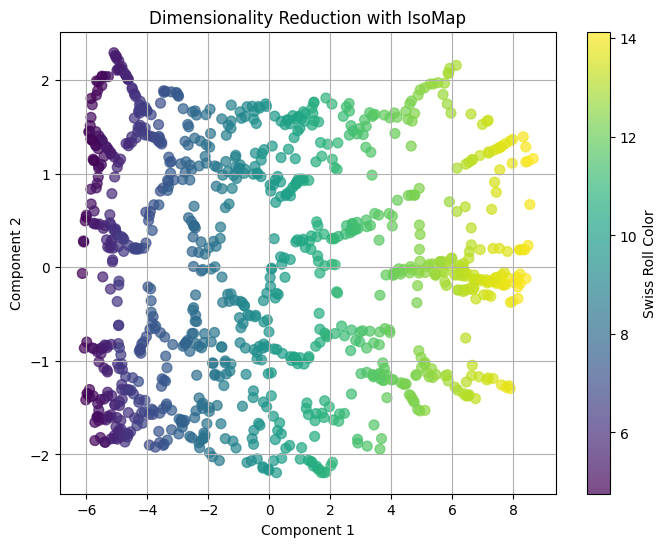

In [76]:
import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# === Data Creation: Swiss Roll Dataset ===
X, color = make_swiss_roll(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

# === Dimensionality Reduction using IsoMap ===
dim_reduction = make_pipeline(
    StandardScaler(),
    Isomap(n_components=2, n_neighbors=5)  # n_neighbors defines local connectivity
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

# === Visualization: Reduced Dimensions ===
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=color, cmap='viridis', s=50, alpha=0.7)
plt.title("Dimensionality Reduction with IsoMap")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label='Swiss Roll Color')
plt.grid(True)
plt.show()

### LLE (Locally Linear Embedding)
**When to use:** When you want to preserve local properties of the data.
**Suitable for:** Non-linear data where local structure is important.

In [77]:
import numpy as np
from sklearn.datasets import make_swiss_roll

# Create a dataset that lies on a non-linear manifold
# LLE works well with manifold data where local structure is important
X, color = make_swiss_roll(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

# For dimensionality reduction, we typically fit on the full dataset
# No need for train/test split, unless you're using the reduced features for a supervised task

In [78]:
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and LLE
dim_reduction = make_pipeline(
    StandardScaler(),
    LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

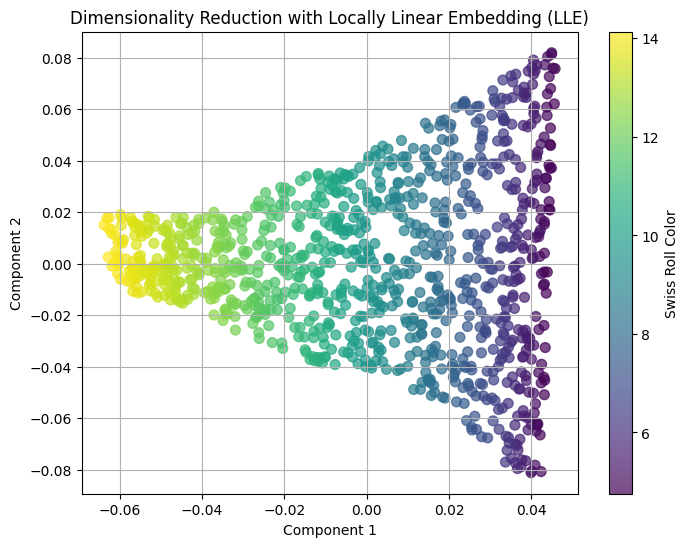

In [79]:
import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# === Data Creation: Swiss Roll Dataset ===
X, color = make_swiss_roll(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

# === Dimensionality Reduction using Locally Linear Embedding (LLE) ===
dim_reduction = make_pipeline(
    StandardScaler(),
    LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)  # n_neighbors defines local connectivity
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

# === Visualization: Reduced Dimensions ===
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=color, cmap='viridis', s=50, alpha=0.7)
plt.title("Dimensionality Reduction with Locally Linear Embedding (LLE)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label='Swiss Roll Color')
plt.grid(True)
plt.show()

### Kernel Approximation
**When to use:** When you want to use kernel methods for dimensionality reduction efficiently.
**Suitable for:** Large datasets where explicit kernel computations would be too expensive.

In [80]:
import numpy as np
from sklearn.datasets import make_classification

# Create a large dataset with non-linear patterns
# Kernel approximation is useful for large datasets with non-linear relationships
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    n_clusters_per_class=3,
    random_state=42
)

# Split the data if you're using the transformed features for a supervised task
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
from sklearn.kernel_approximation import Nystroem
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline with standardization and Nystroem kernel approximation
dim_reduction = make_pipeline(
    StandardScaler(),
    Nystroem(kernel='rbf', n_components=2, random_state=42)
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

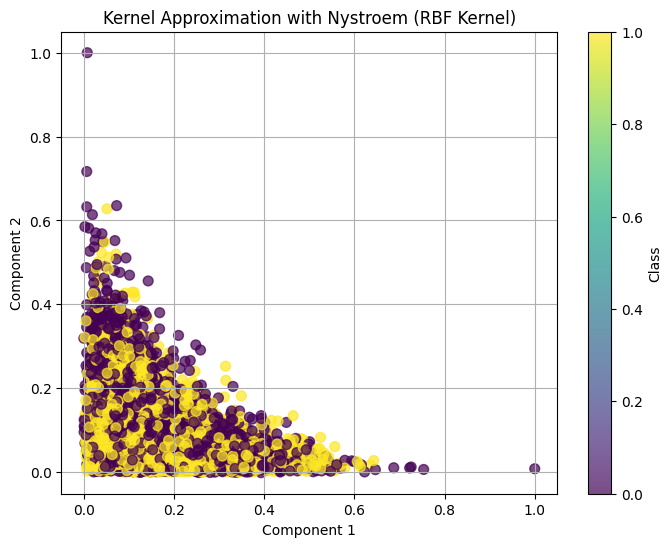

In [82]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.kernel_approximation import Nystroem
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# === Data Creation: Large Dataset with Non-Linear Patterns ===
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    n_clusters_per_class=3,
    random_state=42
)

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Kernel Approximation using Nystroem ===
dim_reduction = make_pipeline(
    StandardScaler(),
    Nystroem(kernel='rbf', n_components=2, random_state=42)  # Nystroem kernel approximation
)

# Fit and transform the data
X_reduced = dim_reduction.fit_transform(X)

# === Visualize the Reduced Dimensions ===
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
plt.title("Kernel Approximation with Nystroem (RBF Kernel)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label='Class')
plt.grid(True)
plt.show()